### Business Problem

Swiggy processes millions of food-delivery journeys across hundreds of cities every month. Accurate Estimated Time of Arrival (ETA) at order placement and during delivery is core to the customer experience — it affects conversion, cancellations, ratings, and retention. Today’s ETA accuracy suffers from many sources of uncertainty: highly variable traffic patterns, weather events, restaurant preparation variability, rider behaviour and skill, order batching/multiple deliveries, and city-specific operational constraints. Inaccurate ETAs cause:
+ Reduced customer trust and lower repeat orders.
+ Increased cancellations and refund costs.
+ Higher support volume and operational interventions.
+ Sub-optimal rider allocation and increased rider idle or overtime costs.

#### Problem Statement

Swiggy’s objective is to predict the delivery time (minutes) per order at the moment of order placement (and update it dynamically), with business-grade accuracy and uncertainty estimates so the platform can
 
 (a) show reliable ETAs to customers
 
 (b) optimize rider allocation.
Build a production-ready, scalable Machine Learning system that predicts per-order delivery time (in minutes) using real-time and historical features (order, rider, restaurant, geospatial, traffic, weather, and temporal signals). The system must produce:

| **Column Name** | **Description** | **Column Name** | **Description** |
|---|---|---|---|
| **Rider_id** | Unique identifier for each delivery partner. | **Age** | Age of the delivery partner. |
| **Ratings** | Average customer rating of the rider. | **Vehicle_condition** | Condition of the vehicle (0 = Poor, 1 = Average, 2 = Good). |
| **Type_of_vehicle** | Vehicle used for delivery. | **Type_of_order** | Type of food ordered (snack, meal, drinks, buffet). |
| **Multiple_deliveries** | Number of deliveries assigned in a single trip. | **Pickup_time_minutes** | Time taken by the restaurant to prepare the order. |
| **Distance** | Distance between restaurant and delivery location in km. | **Restaurant_longitude** | Longitude of the restaurant. |
| **Delivery_longitude** | Longitude of the delivery location. | **Is_weekend** | Indicates whether the order was placed on a weekend. |
| **Order_time_hour** | Hour when the order was placed (0–23). | **Order_time_of_day** | Time bucket (morning, afternoon, evening, night). |
| **Weather** | Weather condition during delivery. | **Traffic** | Traffic condition during delivery. |
| **Festival** | Indicates whether the order was placed on a festival day. | **City_type** | Classification of the city (urban, metropolitan). |
| **City_name** | Name/code of the city (BANG, HYD, CHEN, etc.). | **Time_taken** | Actual time taken to complete the delivery in minutes. |
| **Order_date** | Date when the order was placed. | **Order_day** | Day of the month. |
| **Order_month** | Month of the order. | **Order_day_of_week** | Day of the week (Monday–Sunday). |

In [113]:
import pandas as pd
import numpy as np

In [114]:
df = pd.read_csv("swiggy_demographic.csv")

In [115]:
df.head(5)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


### Understanding the dataset

In [116]:
df.shape

(45502, 26)

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              45502 non-null  object 
 1   age                   43648 non-null  float64
 2   ratings               43594 non-null  float64
 3   restaurant_latitude   41872 non-null  float64
 4   restaurant_longitude  41872 non-null  float64
 5   delivery_latitude     41872 non-null  float64
 6   delivery_longitude    41872 non-null  float64
 7   order_date            45502 non-null  object 
 8   weather               44977 non-null  object 
 9   traffic               44992 non-null  object 
 10  vehicle_condition     45502 non-null  int64  
 11  type_of_order         45502 non-null  object 
 12  type_of_vehicle       45502 non-null  object 
 13  multiple_deliveries   44509 non-null  float64
 14  festival              45274 non-null  object 
 15  city_type          

In [118]:
df.describe()

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,vehicle_condition,multiple_deliveries,time_taken,order_day,order_month,is_weekend,pickup_time_minutes,order_time_hour,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,44509.000000,45502.000000,45502.000000,45502.000000,45502.000000,43862.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,1.019406,0.744928,26.297591,13.811657,2.980726,0.274867,9.989399,17.423966,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,0.835229,0.572488,9.386419,8.709540,0.546031,0.446452,4.087516,4.817856,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,1.000000,2.000000,0.000000,5.000000,0.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,0.000000,0.000000,19.000000,6.000000,3.000000,0.000000,5.000000,15.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,1.000000,1.000000,26.000000,13.000000,3.000000,0.000000,10.000000,19.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000,32.000000,20.000000,3.000000,1.000000,15.000000,21.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000,31.000000,4.000000,1.000000,15.000000,23.000000,20.969489


In [119]:
df.duplicated().sum()

np.int64(0)

In [120]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

In [121]:
df.isna().sum()

rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     1640
order_time_hour         1640
order_time_of_day          0
distance                3630
dtype: int64

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              45502 non-null  object 
 1   age                   43648 non-null  float64
 2   ratings               43594 non-null  float64
 3   restaurant_latitude   41872 non-null  float64
 4   restaurant_longitude  41872 non-null  float64
 5   delivery_latitude     41872 non-null  float64
 6   delivery_longitude    41872 non-null  float64
 7   order_date            45502 non-null  object 
 8   weather               44977 non-null  object 
 9   traffic               44992 non-null  object 
 10  vehicle_condition     45502 non-null  int64  
 11  type_of_order         45502 non-null  object 
 12  type_of_vehicle       45502 non-null  object 
 13  multiple_deliveries   44509 non-null  float64
 14  festival              45274 non-null  object 
 15  city_type          

In [123]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

In [124]:
# drop unecessary columns
df.drop(columns = ['rider_id', 'restaurant_latitude','restaurant_longitude', 'delivery_latitude', 'delivery_longitude', 'order_date'], inplace=True)

In [125]:
df.columns = ['age','ratings','weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance']


#### Target Column

In [126]:
df['time_taken'].describe()

count    45502.000000
mean        26.297591
std          9.386419
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: time_taken, dtype: float64

### EDA

In [127]:
ordinal_cols = ['traffic', 'city_type']
nominal_cols = ['weather', 'type_of_order', 'type_of_vehicle', 'festival','order_day_of_week','city_name', 'order_time_of_day']
numeric_cols = ['age','ratings','vehicle_condition','is_weekend', 'multiple_deliveries', 'pickup_time_minutes','order_time_hour','distance']

In [128]:
df[numeric_cols].skew()

age                   -0.014542
ratings               -1.793118
vehicle_condition      0.060683
is_weekend             1.008587
multiple_deliveries    0.325004
pickup_time_minutes    0.003900
order_time_hour       -1.023568
distance               0.325018
dtype: float64

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

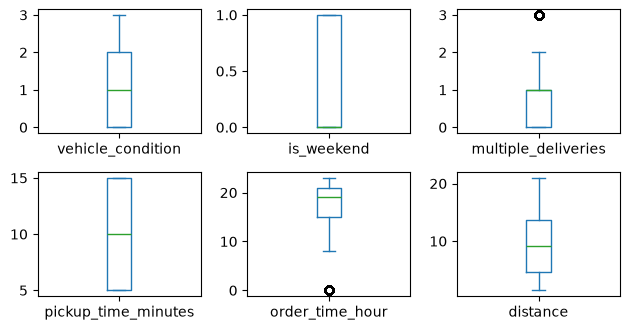

In [130]:
# Box-plot --> Numeric columns
plt.subplot(3,3,1)
df['vehicle_condition'].plot(kind='box')
plt.subplot(3,3,2)
df['is_weekend'].plot(kind='box')
plt.subplot(3,3,3)
df['multiple_deliveries'].plot(kind='box')
plt.subplot(3,3,4)
df['pickup_time_minutes'].plot(kind='box')
plt.subplot(3,3,5)
df['order_time_hour'].plot(kind='box')
plt.subplot(3,3,6)
df['distance'].plot(kind='box')
plt.tight_layout();

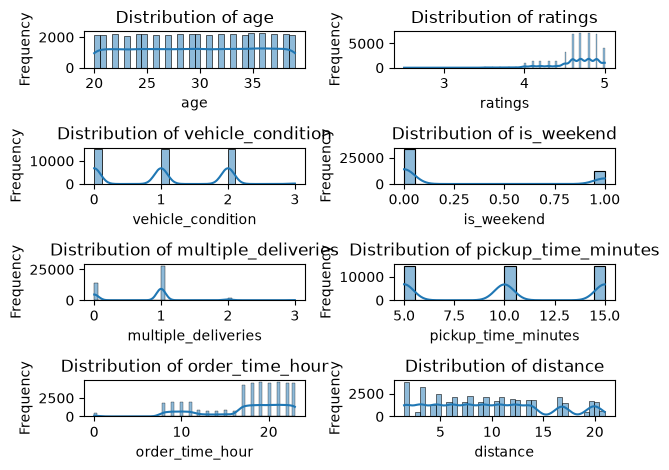

In [131]:
# histplot
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 2, i)  
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show();

#### Target distribution

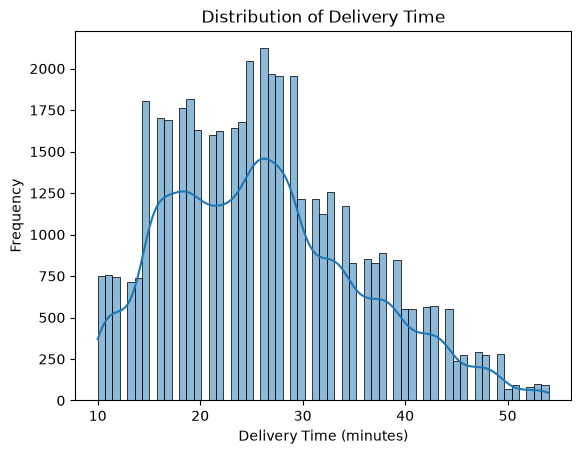

In [132]:
sns.histplot(df["time_taken"], kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.show();

#### Delivery time vs distance

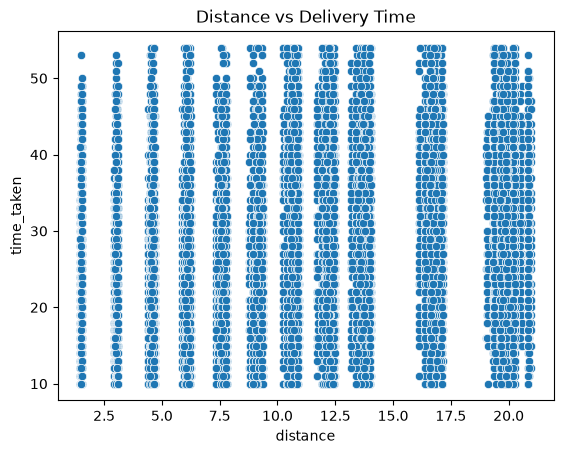

In [133]:
# scatterplot
sns.scatterplot(data=df, x="distance", y="time_taken")
plt.title("Distance vs Delivery Time")
plt.show();

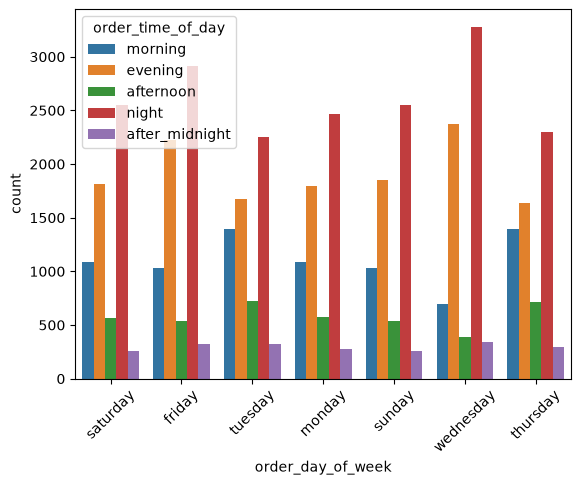

In [134]:
# week vs day
sns.countplot(data=df, x='order_day_of_week', hue='order_time_of_day')
plt.xticks(rotation=45)
plt.show();

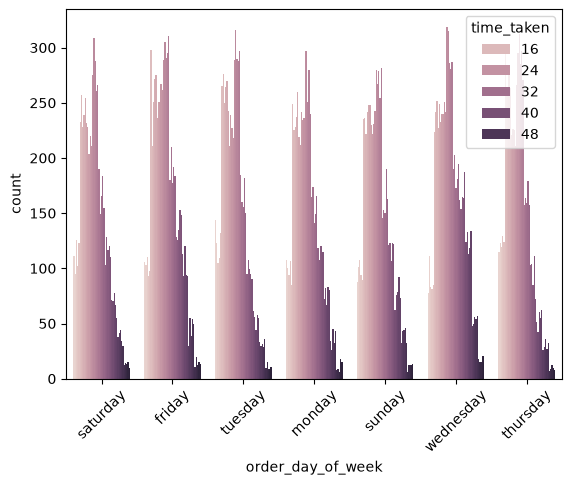

In [135]:
# week vs time_taken
sns.countplot(data=df, x='order_day_of_week', hue='time_taken')
plt.xticks(rotation=45)
plt.show();

#### Correlation 

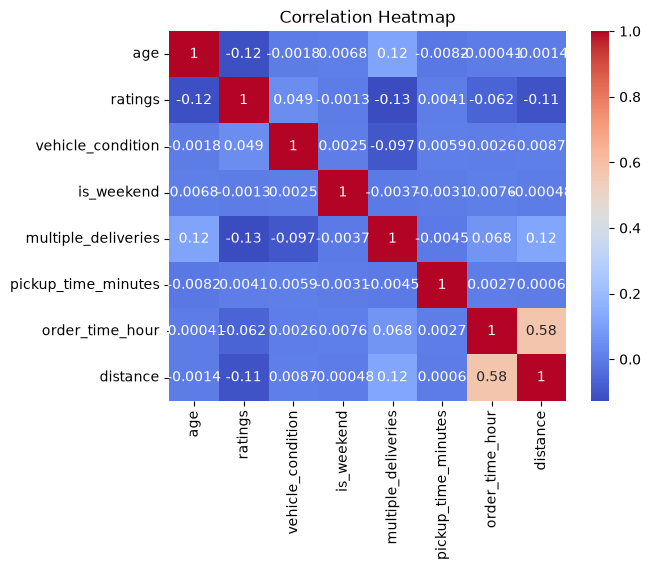

In [136]:
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show();

### splitting data for train/test

In [137]:
x = df.drop(columns=['time_taken'])
y = df['time_taken']

#### Preprocessing using Pipeline

In [138]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

##### Nominal Transformer

In [139]:
nominal_transformer = Pipeline([('Mode Imputation', SimpleImputer(strategy='most_frequent')),
                        ('One Hot Encoding', OneHotEncoder(handle_unknown='ignore'))])
nominal_transformer

,steps,"[('Mode Imputation', ...), ('One Hot Encoding', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


##### Ordinal Transformer

In [140]:
ordinal_transformer = Pipeline([('Mode Imputation', SimpleImputer(strategy = 'most_frequent')),
                               ('Ordinal Encoding', OrdinalEncoder( categories=[["low", "medium", "high", "jam"], ['semi-urban', 'urban', 'metropolitian']]))])
ordinal_transformer

,steps,"[('Mode Imputation', ...), ('Ordinal Encoding', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,"[['low', 'medium', ...], ['semi-urban', 'urban', ...]]"


##### Numeric Transformer

In [141]:
numeric_tranformer = Pipeline([('imputer', KNNImputer(n_neighbors=3)),
                            ('scaler', StandardScaler())])

In [142]:
from sklearn.compose import ColumnTransformer

In [143]:
Preprocessor = ColumnTransformer([('Numerical Transformer', numeric_tranformer, numeric_cols),
                                  ('Nominal Transformer', nominal_transformer, nominal_cols),
                                  ('Ordinal Transformer', ordinal_transformer, ordinal_cols)])
Preprocessor

,transformers,"[('Numerical Transformer', ...), ('Nominal Transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,3
,weights,'uniform'


### Model Building

### Feature Selection — Mutual Information

In [144]:
from sklearn.feature_selection import mutual_info_regression

In [145]:
from sklearn.model_selection import train_test_split

In [146]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [147]:
x_train_processed = Preprocessor.fit_transform(x_train)
x_test_processed = Preprocessor.transform(x_test)

In [148]:
mi_score = mutual_info_regression(x_train_processed, y_train, random_state=23)
mi_score

array([7.78255707e-02, 1.67261014e-01, 6.07496322e-02, 0.00000000e+00,
       1.20514360e-01, 0.00000000e+00, 1.31230871e-01, 1.13114038e-01,
       1.13697428e-02, 1.16854752e-02, 5.92693078e-03, 1.37624218e-03,
       3.11733794e-02, 6.20268930e-03, 1.54749982e-03, 0.00000000e+00,
       0.00000000e+00, 2.58339908e-03, 3.52164945e-04, 3.25964436e-03,
       1.76297606e-02, 1.61093985e-02, 4.79065520e-02, 4.79065520e-02,
       2.82337462e-03, 0.00000000e+00, 3.94081546e-04, 0.00000000e+00,
       9.49480309e-04, 6.01283098e-03, 7.26241983e-04, 2.33907581e-04,
       4.80678862e-04, 0.00000000e+00, 6.72699008e-04, 2.32839005e-04,
       0.00000000e+00, 0.00000000e+00, 8.89810042e-04, 9.28908697e-04,
       1.91139139e-03, 0.00000000e+00, 8.12489306e-05, 0.00000000e+00,
       5.36103152e-04, 2.99083789e-04, 6.66434506e-04, 0.00000000e+00,
       7.51152620e-04, 0.00000000e+00, 3.51149764e-04, 0.00000000e+00,
       1.79716911e-04, 1.82453754e-03, 6.72462830e-03, 1.28038476e-02,
      

In [149]:
feature_names = Preprocessor.get_feature_names_out()
print("Number of features:", len(feature_names))
print('Number of MI score:', len(mi_score))

Number of features: 60
Number of MI score: 60


In [150]:
mi_df = pd.DataFrame({
    'Feature': feature_names,
    'MI_Score': mi_score
})

mi_df = mi_df.sort_values(
    by='MI_Score',
    ascending=False
)

mi_df

,Feature,MI_Score
1,Numerical Transformer__ratings,0.167261
6,Numerical Transformer__order_time_hour,0.131231
4,Numerical Transformer__multiple_deliveries,0.120514
58,Ordinal Transformer__traffic,0.118087
7,Numerical Transformer__distance,0.113114
0,Numerical Transformer__age,0.077826
2,Numerical Transformer__vehicle_condition,0.060750
23,Nominal Transformer__festival_yes,0.047907
22,Nominal Transformer__festival_no,0.047907
56,Nominal Transformer__order_time_of_day_morning,0.039205


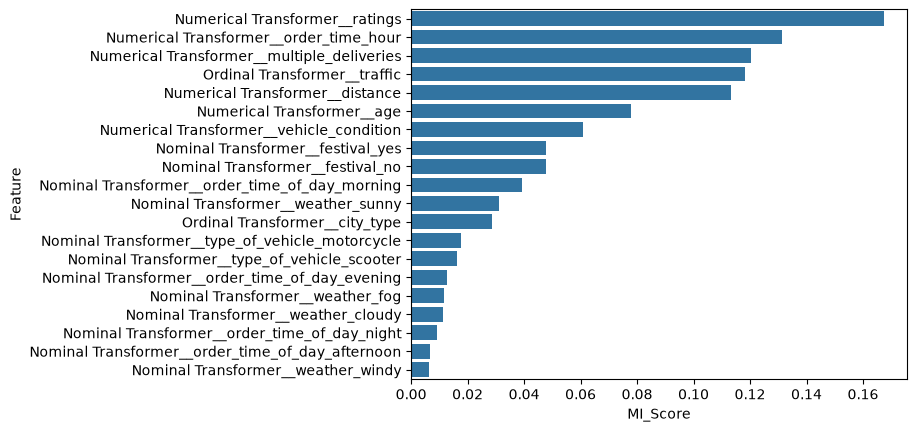

In [151]:
top_mi = mi_df.head(20)
sns.barplot(data=top_mi, x='MI_Score',y='Feature')
plt.show()

#### RFE

In [152]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [153]:
lr = LinearRegression()
n_features = x_train_processed.shape[1]
print('Total processed features:', n_features)

Total processed features: 60


In [154]:
n_select = n_features // 2
print("Features to select:", n_select)

Features to select: 30


In [155]:
rfe = RFE(estimator=lr, n_features_to_select = n_select, step=1)

In [156]:
rfe.fit(x_train_processed, y_train)

,estimator,LinearRegression()
,n_features_to_select,30
,step,1
,verbose,0
,importance_getter,'auto'
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [157]:
rfe_results = pd.DataFrame({'Feature': feature_names, 'selected': rfe.support_, 'Ranking':rfe.ranking_})
rfe_results = rfe_results.sort_values(by='Ranking')
rfe_results

,Feature,selected,Ranking
0,Numerical Transformer__age,True,1
21,Nominal Transformer__type_of_vehicle_scooter,True,1
22,Nominal Transformer__festival_no,True,1
23,Nominal Transformer__festival_yes,True,1
28,Nominal Transformer__order_day_of_week_thursday,True,1
58,Ordinal Transformer__traffic,True,1
30,Nominal Transformer__order_day_of_week_wednesday,True,1
32,Nominal Transformer__city_name_ALH,True,1
35,Nominal Transformer__city_name_BHP,True,1
43,Nominal Transformer__city_name_KNP,True,1


In [158]:
selected_rfe_features = rfe_results[ rfe_results['selected'] == True ]
selected_rfe_features

,Feature,selected,Ranking
0,Numerical Transformer__age,True,1
21,Nominal Transformer__type_of_vehicle_scooter,True,1
22,Nominal Transformer__festival_no,True,1
23,Nominal Transformer__festival_yes,True,1
28,Nominal Transformer__order_day_of_week_thursday,True,1
58,Ordinal Transformer__traffic,True,1
30,Nominal Transformer__order_day_of_week_wednesday,True,1
32,Nominal Transformer__city_name_ALH,True,1
35,Nominal Transformer__city_name_BHP,True,1
43,Nominal Transformer__city_name_KNP,True,1


#### Forward Selection

In [159]:
from sklearn.feature_selection import SequentialFeatureSelector

In [160]:
sfs = SequentialFeatureSelector(lr, n_features_to_select = n_select, direction = 'forward', scoring = 'r2', cv=5)

In [161]:
x_train_selected = sfs.fit_transform(x_train_processed, y_train)

In [162]:
x_test_selected = sfs.transform(x_test_processed)

In [163]:
sfs_results = pd.DataFrame({'Feature':feature_names, 'Selected': sfs.get_support()})
sfs_results = sfs_results[sfs_results['Selected'] == True]
sfs_results

,Feature,Selected
0,Numerical Transformer__age,True
1,Numerical Transformer__ratings,True
2,Numerical Transformer__vehicle_condition,True
3,Numerical Transformer__is_weekend,True
4,Numerical Transformer__multiple_deliveries,True
5,Numerical Transformer__pickup_time_minutes,True
6,Numerical Transformer__order_time_hour,True
7,Numerical Transformer__distance,True
8,Nominal Transformer__weather_cloudy,True
9,Nominal Transformer__weather_fog,True


In [164]:
forward_selected_features = feature_names[ sfs.get_support()]
print(forward_selected_features)

['Numerical Transformer__age' 'Numerical Transformer__ratings'
 'Numerical Transformer__vehicle_condition'
 'Numerical Transformer__is_weekend'
 'Numerical Transformer__multiple_deliveries'
 'Numerical Transformer__pickup_time_minutes'
 'Numerical Transformer__order_time_hour'
 'Numerical Transformer__distance' 'Nominal Transformer__weather_cloudy'
 'Nominal Transformer__weather_fog' 'Nominal Transformer__weather_sunny'
 'Nominal Transformer__type_of_order_drinks'
 'Nominal Transformer__type_of_vehicle_bicycle'
 'Nominal Transformer__type_of_vehicle_electric_scooter'
 'Nominal Transformer__type_of_vehicle_motorcycle'
 'Nominal Transformer__type_of_vehicle_scooter'
 'Nominal Transformer__festival_no' 'Nominal Transformer__festival_yes'
 'Nominal Transformer__order_day_of_week_thursday'
 'Nominal Transformer__order_day_of_week_tuesday'
 'Nominal Transformer__order_day_of_week_wednesday'
 'Nominal Transformer__city_name_ALH' 'Nominal Transformer__city_name_BHP'
 'Nominal Transformer__city

#### Linear Regression

In [165]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [166]:
lr = LinearRegression()
lr.fit(x_train_selected, y_train)
lr_pred = lr.predict(x_test_selected)
mae_lr = mean_absolute_error(y_test, lr_pred)
mse_lr = mean_squared_error(y_test, lr_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, lr_pred)
print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 4.896766061051787
MSE : 37.95248802435963
RMSE: 6.1605590675164885
R²  : 0.5685306038468781


#### Decision Tree Regression

In [167]:
from sklearn.tree import DecisionTreeRegressor

In [168]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train_selected, y_train)
dt_pred = dt.predict(x_test_selected)
mae_dt = mean_absolute_error(y_test, dt_pred)
mse_dt = mean_squared_error(y_test, dt_pred)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, dt_pred)
print("Decision Tree Regression Results")
print("-------------------------")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Regression Results
-------------------------
MAE : 4.3010658169431935
MSE : 32.65663113943523
RMSE: 5.714598073306226
R²  : 0.6287374648775719


#### XGBRegressor

In [169]:
from xgboost import XGBRegressor

In [170]:
gb = XGBRegressor(random_state=42)
gb.fit(x_train_selected, y_train)
gb_pred = gb.predict(x_test_selected)
mae_gb = mean_absolute_error(y_test, gb_pred)
mse_gb = mean_squared_error(y_test, gb_pred)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, gb_pred)
print("XGBRegressor Results")
print("-------------------------")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

XGBRegressor Results
-------------------------
MAE : 3.2989859580993652
MSE : 17.46083641052246
RMSE: 4.1786165665830675
R²  : 0.8014934659004211


#### Model selection

In [171]:
models_predictions = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Gradient Boosting": gb_pred
}
results = []
for name, pred in models_predictions.items():
    mae_value = mean_absolute_error(y_test, pred)
    mse_value = mean_squared_error(y_test, pred)
    rmse_value = np.sqrt(mse_value)
    r2_value = r2_score(y_test, pred)

    results.append([
        name,
        mae_value,
        mse_value,
        rmse_value,
        r2_value
    ])
model_comparison = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)
model_comparison

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,4.896766,37.952488,6.160559,0.568531
1,Decision Tree,4.301066,32.656631,5.714598,0.628737
2,Gradient Boosting,3.298986,17.460836,4.178617,0.801493


### Cross-Validation

In [172]:
from sklearn.model_selection import cross_val_score

In [173]:
xgb = XGBRegressor(random_state=42,objective='reg:squarederror')

In [174]:
cv_scores = cross_val_score(xgb, x_train_selected, y_train, cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1)

# neg_root_mean_squared_error is negative by design, so we use - to display the actual RMSE.

In [175]:
cv_rmse = -cv_scores
print("XGBoost Cross-Validation RMSE:")
print(cv_rmse)

print("\nMean CV RMSE:", cv_rmse.mean())
print("Std CV RMSE :", cv_rmse.std())

XGBoost Cross-Validation RMSE:
[4.19916296 4.19778061 4.14097881 4.19643259 4.1680994 ]

Mean CV RMSE: 4.180490875244141
Std CV RMSE : 0.02287562702065149


### XGBoost Hyperparameter Tuning

In [176]:
from sklearn.model_selection import GridSearchCV

In [177]:
xgb_param_grid={'n_estimators':[100,200],'max_depth':[3,5,7],'learning_rate':[0.05,0.1],'subsample':[0.8,1.0], 'colsample_bytree':[0.8, 1.0]}

In [178]:
xgb_grid = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective='reg:squarederror'
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(x_train_selected, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [179]:
print("Best Parameters:")
print(xgb_grid.best_params_)

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [180]:
print("Best CV RMSE:")
print(-xgb_grid.best_score_)

Best CV RMSE:
4.084105682373047


In [181]:
best_xgb = xgb_grid.best_estimator_

In [182]:
best_xgb_pred = best_xgb.predict(x_test_selected)

In [183]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, best_xgb_pred)
xgb_mse = mean_squared_error(y_test, best_xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, best_xgb_pred)

print("Tuned XGBoost Results")
print("---------------------")
print("MAE :", xgb_mae)
print("MSE :", xgb_mse)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

Tuned XGBoost Results
---------------------
MAE : 3.2307021617889404
MSE : 16.686370849609375
RMSE: 4.084895451490696
R²  : 0.8102981448173523


### Final Model 

In [184]:
from xgboost import XGBRegressor

xgb_best = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    random_state=23
)
xgb_best.fit(x_train_selected, y_train)
y_pred = xgb_best.predict(x_test_selected)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8125972747802734


### Check overfitting/underfitting

In [185]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predictions
y_train_pred = xgb_best.predict(x_train_selected)
y_test_pred = xgb_best.predict(x_test_selected)

# R²
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("XGBoost Train R² :", train_r2)
print("XGBoost Test R²  :", test_r2)

print("\nXGBoost Train RMSE :", train_rmse)
print("XGBoost Test RMSE  :", test_rmse)

XGBoost Train R² : 0.8644229173660278
XGBoost Test R²  : 0.8125972747802734

XGBoost Train RMSE : 3.456754270330655
XGBoost Test RMSE  : 4.060065611135322


### Deployment

In [186]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ('preprocessor', Preprocessor),
    ('feature_selection', sfs),
    ('model', xgb_best)
])
final_pipeline

,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical Transformer', ...), ('Nominal Transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Testing

In [187]:
final_pred = final_pipeline.predict(x_test)
from sklearn.metrics import r2_score
final_r2 = r2_score(y_test, final_pred)
print("Final Pipeline R²:", final_r2)

Final Pipeline R²: 0.8125972747802734


#### Save the final pipeline

In [188]:
import joblib
joblib.dump(final_pipeline, "delivery_time_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [189]:
loaded_model = joblib.load("delivery_time_model.pkl")
loaded_pred = loaded_model.predict(x_test)
loaded_r2 = r2_score(y_test, loaded_pred)
print("Loaded Model R²:", loaded_r2)

Loaded Model R²: 0.8125972747802734


In [190]:
import sklearn
print(sklearn.__version__)

1.7.2
